In [3]:
import pandas as pd
import numpy as np


In [4]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer


In [5]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])


In [6]:
df.dropna(inplace = True)
df.shape

(714, 3)

In [7]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
X_train.head(2)


,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [12]:
clf = DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [13]:
accuracy_score(y_test,y_pred)

0.6223776223776224

In [14]:
np.mean(cross_val_score(clf,X,y,cv=5,scoring='accuracy'))

0.6176598049837487

In [16]:
kbins_age = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')


In [22]:
trf = ColumnTransformer([
    ('first',kbins_age,[0]),
                        ('second',kbin_fare,[1])])

In [23]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [24]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [25]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [27]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]

})

In [28]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                              bins = trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                bins = trf.named_transformers_['second'].bin_edges_[0].tolist())

In [29]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
25,38.0,7.0,31.3875,7.0,"(36.0, 42.0]","(29.125, 51.479]"
252,62.0,9.0,26.5500,6.0,"(50.0, 80.0]","(26.0, 29.125]"
833,23.0,3.0,7.8542,1.0,"(22.0, 25.0]","(7.75, 7.896]"
233,5.0,0.0,31.3875,7.0,"(0.42, 14.0]","(29.125, 51.479]"
625,61.0,9.0,32.3208,7.0,"(50.0, 80.0]","(29.125, 51.479]"


In [30]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred = clf.predict(X_test_trf)

In [32]:
accuracy_score(y_test,y_pred)

0.6223776223776224

In [33]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv = 10,scoring='accuracy'))

0.6317292644757433

In [36]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf = ColumnTransformer([
        ( 'first',kbin_age,[0]),
                            ('second',kbin_fare,[1])])

0.682140062597809


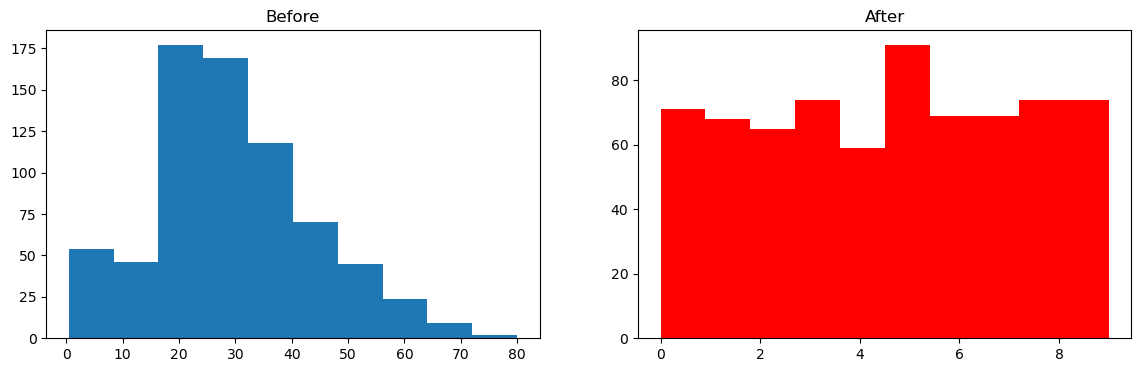

In [37]:
X_trf = trf.fit_transform(X)
print(np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv = 10,scoring='accuracy')))

plt.figure(figsize=(14,4))
plt.subplot(121)
plt.hist(X['Age'])
plt.title('Before')

plt.subplot(122)
plt.hist(X_trf[:,0],color ='red')
plt.title('After')

plt.show()

In [40]:
discretize(10,'quantile')
plt.show()

In [41]:
discretize(10,'uniform')